In [0]:
!kill -9 -1

In [0]:
from google.colab import drive
drive.mount('/content/gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/gdrive


In [0]:
import keras
from keras.models import Sequential,Model
from keras.layers import Dense,Dropout,Flatten,Input
from keras.layers import Conv2D,MaxPooling2D,AveragePooling2D,ZeroPadding2D
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from keras import optimizers

Using TensorFlow backend.


In [0]:
num_class=7
img_width,img_height=84,84

train_data_dir ='/content/gdrive/My Drive/face_mtcnn/MTCNN_train'                               
validation_data_dir ='/content/gdrive/My Drive/face_mtcnn/MTCNN_validation'                     
nb_train_samples=5600                                                          
nb_validation_samples=2100                                                           
epochs=50                                                                          
batch_size=32                                                                        

In [0]:
#Input layer
input_layer=Input(shape=(84,84,3))
#Convolutional layer 1
layer1=Conv2D(16,kernel_size=(3,3),strides=(1,1),activation='relu')(input_layer)

#Convolutional layer 2
#layer2=Conv2D(32,kernel_size=(3,3),strides=(1,1),activation='relu')(layer1)
layer2=MaxPooling2D(pool_size=(3,3),strides=(2,2))(layer1)

#Convolutional layer 3
layer3=Conv2D(32,kernel_size=(4,4),strides=(1,1),activation='relu')(layer2)

#Convolutional layer 4
#layer4=Conv2D(16,kernel_size=(2,2),strides=(1,1),activation='relu')(layer3)
layer4=MaxPooling2D(pool_size=(3,3),strides=(2,2))(layer3)

#Convolutional layer 5
#layer51=Conv2D(128,kernel_size=(3,3),strides=(1,1),activation='relu')(layer4)
#layer51=MaxPooling2D(pool_size=(3,3),strides=(2,2))(layer51)

layer5=Flatten()(layer4)
#Fully connected layer-1
layer6=Dense(1024,activation='relu')(layer5)
layer7=Dense(512,activation='relu')(layer6)
layer9=Dense(128,activation='relu')(layer6)
#Output softmax layer
predictions=Dense(num_class,activation='softmax')(layer9)

#This defines a model with input_layer as input layer and predictions as a output layer
model = Model(inputs=input_layer, outputs=predictions)

print(model.input)
print(model.output)


Instructions for updating:
Colocations handled automatically by placer.
Tensor("input_1:0", shape=(?, 84, 84, 3), dtype=float32)
Tensor("dense_4/Softmax:0", shape=(?, 7), dtype=float32)


In [0]:
print(model.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 84, 84, 3)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 82, 82, 16)        448       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 40, 40, 16)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 37, 37, 32)        8224      
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 18, 18, 32)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 10368)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 1024)              10617856  
__________

In [0]:
     print('Model loaded')
adam=optimizers.adam(lr=0.0001)
model.compile(optimizer=adam,loss='categorical_crossentropy',metrics=['accuracy'])

Model loaded


In [0]:
# prepare data augmentation configuration
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')

validation_generator =val_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')

Found 8289 images belonging to 7 classes.
Found 2049 images belonging to 7 classes.


In [0]:
#Fit the model
history=model.fit_generator(
    train_generator,
    samples_per_epoch=nb_train_samples,
    epochs=epochs,
    validation_data=validation_generator,
    nb_val_samples=nb_validation_samples)

Instructions for updating:
Use tf.cast instead.


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:6: UserWarning: The semantics of the Keras 2 argument `steps_per_epoch` is not the same as the Keras 1 argument `samples_per_epoch`. `steps_per_epoch` is the number of batches to draw from the generator at each epoch. Basically steps_per_epoch = samples_per_epoch/batch_size. Similarly `nb_val_samples`->`validation_steps` and `val_samples`->`steps` arguments have changed. Update your method calls accordingly.
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:6: UserWarning: Update your `fit_generator` call to the Keras 2 API: `fit_generator(<keras_pre..., epochs=50, validation_data=<keras_pre..., steps_per_epoch=175, validation_steps=2100)`
  


Epoch 1/50
175/175 [==============================] - 2425s 14s/step - loss: 1.6393 - acc: 0.3070 - val_loss: 2.4582 - val_acc: 0.2149
Epoch 2/50
175/175 [==============================] - 1044s 6s/step - loss: 1.3181 - acc: 0.4932 - val_loss: 2.7376 - val_acc: 0.3310
Epoch 3/50
175/175 [==============================] - 355s 2s/step - loss: 1.1137 - acc: 0.5798 - val_loss: 2.8899 - val_acc: 0.3558
Epoch 4/50
175/175 [==============================] - 353s 2s/step - loss: 1.0118 - acc: 0.6218 - val_loss: 2.8710 - val_acc: 0.3752
Epoch 5/50
175/175 [==============================] - 353s 2s/step - loss: 0.9552 - acc: 0.6375 - val_loss: 3.0631 - val_acc: 0.3774
Epoch 6/50
175/175 [==============================] - 353s 2s/step - loss: 0.8840 - acc: 0.6666 - val_loss: 3.0562 - val_acc: 0.3977
Epoch 7/50
175/175 [==============================] - 353s 2s/step - loss: 0.8314 - acc: 0.6907 - val_loss: 3.2990 - val_acc: 0.4018
Epoch 8/50
175/175 [==============================] - 355s 2s/step

In [0]:
#list all data in history
print(history.history.keys())

dict_keys(['val_loss', 'val_acc', 'loss', 'acc'])


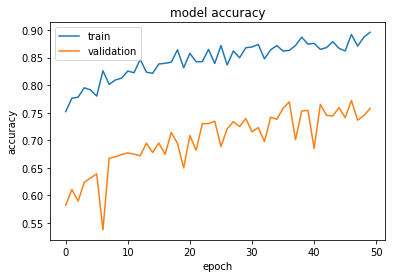

In [0]:
#summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','validation'],loc='upper left')
plt.show()

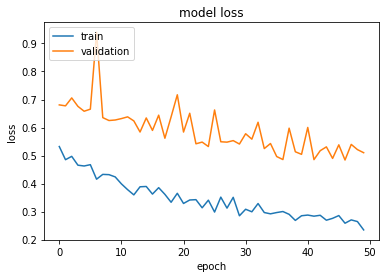

In [0]:
#summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','validation'],loc='upper left')
plt.show()

In [0]:
#save the model to the drive .h5 after training.
model.save("/content/gdrive/My Drive/Happy vs sad/SadvsHappy.h5")

In [0]:
#save the model to the drive .h5 after training.
model.save("/content/SadvsHappy.h5")

In [0]:
!git clone https://github.com/amir-abdi/keras_to_tensorflow.git 

Cloning into 'keras_to_tensorflow'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 156 (delta 0), reused 3 (delta 0), pack-reused 153
Receiving objects: 100% (156/156), 146.29 KiB | 2.99 MiB/s, done.
Resolving deltas: 100% (75/75), done.


In [0]:
!python /content/keras_to_tensorflow/keras_to_tensorflow.py  --input_model="/content/SadvsHappy.h5" --output_model="/content/model.pb"

Using TensorFlow backend.
Instructions for updating:
Colocations handled automatically by placer.
W0422 16:42:52.424566 139737159997312 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/framework/op_def_library.py:263: colocate_with (from tensorflow.python.framework.ops) is deprecated and will be removed in a future version.
Instructions for updating:
Colocations handled automatically by placer.
2019-04-22 16:42:52.560441: I tensorflow/core/platform/profile_utils/cpu_utils.cc:94] CPU Frequency: 2300000000 Hz
2019-04-22 16:42:52.560726: I tensorflow/compiler/xla/service/service.cc:150] XLA service 0x208aec0 executing computations on platform Host. Devices:
2019-04-22 16:42:52.560762: I tensorflow/compiler/xla/service/service.cc:158]   StreamExecutor device (0): <undefined>, <undefined>
Instructions for updating:
Use tf.cast instead.
W0422 16:42:52.829820 139737159997312 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/

In [0]:
!cp /content/model.pb / /content/gdrive/My Drive/Happy vs sad

In [0]:
from tensorflow.contrib import lite
converter = lite.TFLiteConverter.from_keras_model_file( "/content/With_pooling (1).h5" ) # Your model's name
model = converter.convert()
file = open( 'mobile.tflite' , 'wb' ) 
file.write( model )

INFO:tensorflow:Froze 264 variables.
INFO:tensorflow:Converted 264 variables to const ops.


14125768

In [0]:
rm -rf content/inception30_newdata.h5

In [0]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving inception30_newdata.h5 to inception30_newdata (1).h5


In [0]:
from google.colab import files
files.download('/content/mobile.tflite')